In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42) #generate reproducible nonlinear data

X = np.linspace(0,10,40).reshape(-1,1)

y = 2+0.5*X[:,0] ** 2 + np.random.normal(0,5,40)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)
degrees = [1,2,10]
for degree in degrees:
  model = make_pipeline(PolynomialFeatures(degree,include_bias=False),LinearRegression())
  model.fit(X_train,y_train)
  train_prediction = model.predict(X_train)
  y_pred = model.predict(X_test)
  train_mse = mean_squared_error(y_train,train_prediction)
  mse = mean_squared_error(y_test,y_pred)

  print("Polynomal degree",degree)
  print(f"Train MSE {train_mse:.2f}")
  print(f"Test MSE {mse:.2f}")
  

Polynomal degree 1
Train MSE 42.90
Test MSE 42.99
Polynomal degree 2
Train MSE 20.44
Test MSE 19.79
Polynomal degree 10
Train MSE 12.89
Test MSE 95.21


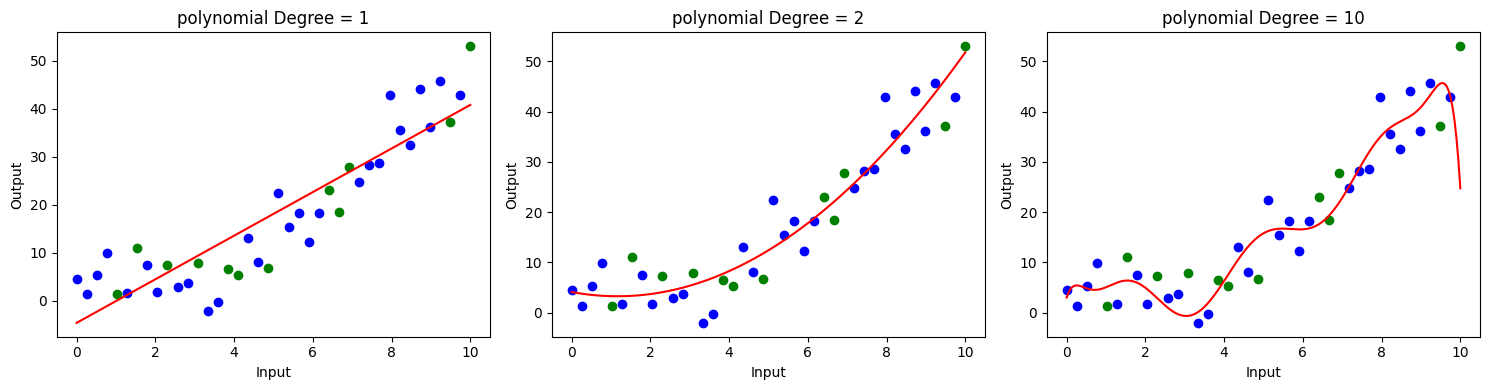

In [4]:
X_plot = np.linspace(0,10,200).reshape(-1,1)
plt.figure(figsize=(15,4))

for index, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree=degree,include_bias=False),
    LinearRegression())

    model.fit(X_train,y_train)
    y_plot = model.predict(X_plot)

    plt.subplot(1,3,index+1)
    plt.scatter(X_train,y_train,color ="blue",label="Training data")
    plt.scatter(X_test,y_test,color="green",label="Testing data")
    plt.plot(X_plot,y_plot,color="red",label="prediction")

    plt.title(f"polynomial Degree = {degree}")
    plt.xlabel("Input")
    plt.ylabel("Output")

plt.tight_layout()
plt.show()

## Cross-validation and model selection

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import numpy as np

for degree in range(1,11):
    model = make_pipeline(
        PolynomialFeatures(degree=degree,include_bias=False),LinearRegression()
    )
    scores = cross_val_score(model,X,y,cv=5,scoring="neg_mean_squared_error")
    mse_score = -scores.mean()
    print(f"Degree {degree}: CV MSE = {mse_score:.2f}")
    

Degree 1: CV MSE = 110.69
Degree 2: CV MSE = 44.22
Degree 3: CV MSE = 71.23
Degree 4: CV MSE = 82.46
Degree 5: CV MSE = 1348.27
Degree 6: CV MSE = 11392.13
Degree 7: CV MSE = 53226.76
Degree 8: CV MSE = 99956.80
Degree 9: CV MSE = 1196598.07
Degree 10: CV MSE = 11490574.52


## Feature selection

In [17]:
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature":[1,1,1,1,1],
    "almost_constant":[0,0,0,0,1],
    "useful_features":[10,20,30,40,50]
})

selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

print("Selected features",list(selected_columns))


Selected features ['almost_constant', 'useful_features']


## Correlation among features

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours":[1,2,3,4,5,6],
    "attendance":[50,55,65,70,80,90],
    "previous_marks":[35,40,50,55,65,75],
    "final_marks":[38,45,52,60,70,82]
})

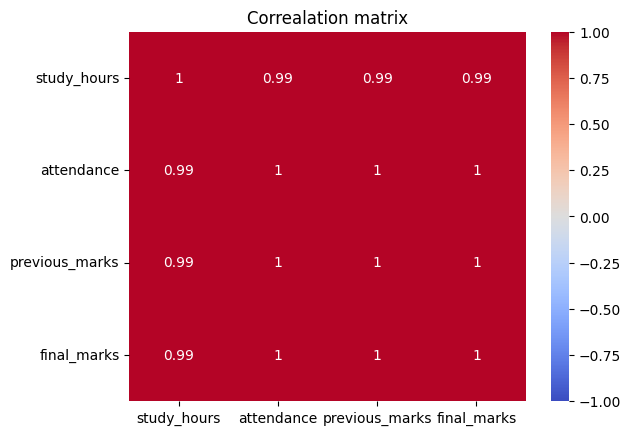

In [21]:
correlation_matrix = data.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correalation matrix")
plt.show()

## Chi-square test

In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X=data.data
y=data.target
X_non_negative = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2,k=5)
X_Selected = selector.fit_transform(X_non_negative,y)
selected_features = data.feature_names[selector.get_support()]

print("Selected features")
print(selected_features)

Selected features
['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


### Univariate Feature Selection

In [26]:
from sklearn.datasets import load_iris


In [27]:
iris = load_iris()
X,y = iris.data, iris.target
X.shape

(150, 4)

In [28]:
X_select = SelectKBest(chi2,k=3).fit_transform(X,y)
X_select

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

### F-test on ANOVA

In [30]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest,f_classif

data = load_iris()
X = data.data
y = data.target

selector = SelectKBest(score_func=f_classif,k=2)
X_selected = selector.fit_transform(X,y)

import numpy as np

selected_features = np.array(data.feature_names)[selector.get_support()]

print("Selected features: ",selected_features)

Selected features:  ['petal length (cm)' 'petal width (cm)']
